## Collect & Prepare Your Own Documents

Task:

1. Create a folder named my_docs/.
2. Place at least 3 text-based files in it — .txt, .md, or extracted .pdf text.
  
Examples:
  - A research paper summary you wrote
  - A blog article about AI or sustainability
  - Course notes or company reports

3. Load them into Python.

In [1]:
import shutil
import os

os.makedirs("my_docs", exist_ok=True)

shutil.copy(os.path.expanduser("~/Downloads/rag_research_summary.txt"), "my_docs/")
shutil.copy(os.path.expanduser("~/Downloads/ai_sustainability_blog.txt"), "my_docs/")
shutil.copy(os.path.expanduser("~/Downloads/embeddings_course_notes.txt"), "my_docs/")

print("Files copied.")
print(os.listdir("my_docs"))

Files copied.
['embeddings_course_notes.txt', 'ai_sustainability_blog.txt', 'rag_research_summary.txt']


In [2]:
import os


folder = "my_docs"
documents = []

# TODO: Load your own files
# Verify their data loaded properly.
# Write a few lines describing what kind of documents they chose and why
for file in os.listdir(folder):
    if file.endswith((".txt", ".md")):
        with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
            documents.append(f.read())

print(f"Loaded {len(documents)} documents.")
print(documents[0][:300])  # preview


Loaded 3 documents.
Course Notes: Embeddings and Vector Search

Embeddings are numerical representations of text, images, or other data,
designed so that items with similar meaning are placed close together in a
high-dimensional vector space. In natural language processing, an embedding
model converts a word, sentence,


## Chunk Your Texts

**Goal**: Break long text into manageable pieces for retrieval.

In [3]:
def chunk_text(text, chunk_size=200):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

# Apply chunking to all documents — try different chunk sizes (100, 200, 400)
for size in [100, 200, 400]:
    test_chunks = []
    for doc in documents:
        test_chunks.extend(chunk_text(doc, chunk_size=size))
    print(f"Chunk size {size}: {len(test_chunks)} total chunks")

# Use chunk_size=200 as the final choice
chunks = []
for doc in documents:
    chunks.extend(chunk_text(doc))  # default chunk_size=200
print("\nTotal chunks created:", len(chunks))

# Of the three chunk sizes tested (100, 200, 400 words), chunk size 200
# is the best balance for this document set. A chunk size of 100 produces
# more, smaller chunks — each one covers a narrower idea, which can improve
# precision but risks splitting a single coherent point across two chunks
# and losing context. A chunk size of 400 produces very few, large chunks
# often an entire document in one chunkwhich keeps full context
# together but reduces retrieval precision, since a matching chunk may
# also contain a lot of unrelated text. 200 words is a reasonable middle
# ground: each chunk is focused enough to return precise context for
# retrieval while still containing a complete idea rather than a fragment.

Chunk size 100: 9 total chunks
Chunk size 200: 6 total chunks
Chunk size 400: 3 total chunks

Total chunks created: 6


## Build Your Own Retriever (Semantic)

**Goal**: Retrieve the most relevant chunks using embeddings.

In [4]:
import sys
!{sys.executable} -m pip install sentence-transformers torch
from sentence_transformers import SentenceTransformer, util
import torch

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# TODO: Embed your chunks
chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True)

def retrieve_chunks(query, k=2):
    query_embed = embedder.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_embed, chunk_embeddings)[0]
    top_k = torch.topk(scores, k)
    return [chunks[i] for i in top_k.indices]

# TEST
print(retrieve_chunks("What is discussed about AI ethics?", k=2))


/Users/gouravss/langchain_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/gouravss/langchain_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['activity, giving environmental agencies tools to respond more quickly than manual monitoring would allow. However, it is worth noting that AI itself has an environmental cost. Training large machine learning models requires significant computational power, which translates into substantial electricity consumption and carbon emissions. As AI adoption grows, there is an increasing need to balance the sustainability benefits AI provides against the environmental footprint of the technology itself, through approaches like model efficiency improvements and renewable powered data centers.', "The Role of AI in Building a More Sustainable Future Artificial intelligence is increasingly being used as a tool to address some of the world's most pressing environmental challenges. From optimizing energy consumption in buildings to predicting extreme weather events, AI systems are helping organizations make faster, data-driven decisions that reduce waste and improve efficiency. One of the clearest 

## Connect Retrieval with Generation

**Goal**: Use retrieved chunks as context for text generation.

In [5]:
from transformers import pipeline

generator = pipeline("text-generation", model="distilgpt2", max_new_tokens=120, temperature=0.3)

def mini_rag(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)
    prompt = f"Use the following context to answer the question:\n\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return generator(prompt)[0]['generated_text']

def no_retrieval(query):
    # Same generation, but with NO retrieved context — just the raw question
    prompt = f"Question: {query}\n\nAnswer:"
    return generator(prompt)[0]['generated_text']

# Try 2-3 questions based on my own documents
questions = [
    "What is retrieval-augmented generation?",
    "How can AI help with sustainability?",
    "What is cosine similarity used for?"
]

for q in questions:
    print("QUESTION:", q)
    print("\n--- WITH retrieval (mini_rag) ---")
    print(mini_rag(q))
    print("\n--- WITHOUT retrieval (no context) ---")
    print(no_retrieval(q))
    print()

Device set to use mps:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


QUESTION: What is retrieval-augmented generation?

--- WITH retrieval (mini_rag) ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Use the following context to answer the question:

Research Summary: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks Retrieval-Augmented Generation, commonly known as RAG, is an approach that combines information retrieval with text generation to produce more accurate and grounded answers from large language models. Traditional language models generate text purely from patterns learned during training, which means they can produce fluent but factually incorrect responses, a problem known as hallucination. RAG addresses this limitation by retrieving relevant documents from an external knowledge source before generating a response. The retrieved documents are added to the model's input as context, so the generation step is grounded in real, verifiable information rather than relying solely on the model's internal parameters. The typical RAG pipeline has three stages. First, a retriever searches a document collection for passages relevant to the user's query, often using 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Use the following context to answer the question:

activity, giving environmental agencies tools to respond more quickly than manual monitoring would allow. However, it is worth noting that AI itself has an environmental cost. Training large machine learning models requires significant computational power, which translates into substantial electricity consumption and carbon emissions. As AI adoption grows, there is an increasing need to balance the sustainability benefits AI provides against the environmental footprint of the technology itself, through approaches like model efficiency improvements and renewable powered data centers.
The Role of AI in Building a More Sustainable Future Artificial intelligence is increasingly being used as a tool to address some of the world's most pressing environmental challenges. From optimizing energy consumption in buildings to predicting extreme weather events, AI systems are helping organizations make faster, data-driven decisions that reduce wast

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Question: How can AI help with sustainability?

Answer: AI is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability.
Question: How can AI help with sustainability?
Answer: AI is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability. It is a very important tool in the field of sustainability

QUESTION: What is cosine similarity used for?

--- WITH retrieval (mini_rag) ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Use the following context to answer the question:

score close to one for very similar texts and close to zero for unrelated texts. When vectors are normalized to unit length, cosine similarity simplifies to a dot product, which is computationally efficient. Vector databases, such as FAISS, Pinecone, or LanceDB, are specialized storage systems designed to index large collections of embeddings and perform fast nearest-neighbor search. Rather than comparing a query vector to every stored vector one by one, these systems use indexing structures that allow approximate nearest neighbor search across millions of vectors in milliseconds, which is essential for building responsive retrieval-augmented applications.
Course Notes: Embeddings and Vector Search Embeddings are numerical representations of text, images, or other data, designed so that items with similar meaning are placed close together in a high-dimensional vector space. In natural language processing, an embedding model converts a 

## Add a LangChain RAG Chain

**Goal**: Chain the retrieval and generation steps modularly.

In [6]:
import sys
!{sys.executable} -m pip install langchain langchain-community

import sys
print("Python being used:", sys.executable)

import importlib.util
print("langchain found:", importlib.util.find_spec("langchain") is not None)

try:
    import langchain
    print("langchain version:", langchain.__version__)
    print("langchain location:", langchain.__file__)
except Exception as e:
    print("Import error:", e)

Python being used: /Users/gouravss/langchain_env/bin/python
langchain found: True
langchain version: 0.1.20
langchain location: /Users/gouravss/langchain_env/lib/python3.9/site-packages/langchain/__init__.py


In [7]:
from langchain.prompts import ChatPromptTemplate
from langchain.schema.runnable import RunnablePassthrough
from langchain_community.llms import HuggingFacePipeline
from langchain.chains import LLMChain

# Wrap the existing generator pipeline for LangChain
llm = HuggingFacePipeline(pipeline=generator)

prompt = ChatPromptTemplate.from_template("""
Context:
{context}
Question:
{question}
Answer clearly and concisely:
""")

# Modified retriever: top 3 instead of top 2
def retrieve_top3(q):
    chunks_found = retrieve_chunks(q, k=3)
    print("Retrieved chunks (top 3):")
    for i, c in enumerate(chunks_found, 1):
        print(f"  {i}. {c[:150]}...")
    return "\n".join(chunks_found)

rag_chain = (
    {"context": retrieve_top3, "question": RunnablePassthrough()}
    | prompt
    | llm
)

# Run the chain
print("\nANSWER (top-3 retrieval)")
print(rag_chain.invoke("What are the key challenges mentioned in my research?"))


# Increasing retrieval from top-2 to top-3 chunks generally provides more
# context for the generator to draw from, which can improve answer quality
# if the additional chunk is genuinely relevant, since the model has more
# real evidence to work with. However, with a small corpus of only three
# documents and six total chunks, adding a third chunk risks pulling in a
# less relevant piece of text just to fill the quota, which can dilute the
# context with unrelated information and make it harder for a small model
# like distilgpt2 to focus on the most useful part. In general, more
# context helps up to a point, but beyond that point it adds noise rather
# than signal — the right number of chunks depends on how much truly
# relevant material exists in the corpus, not just on retrieving more.

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



ANSWER (top-3 retrieval)
Retrieved chunks (top 3):
  1. collection, without the cost and complexity of retraining the model itself. This makes RAG particularly useful for applications where information chan...
  2. activity, giving environmental agencies tools to respond more quickly than manual monitoring would allow. However, it is worth noting that AI itself h...
  3. Research Summary: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks Retrieval-Augmented Generation, commonly known as RAG, is an approa...
Human: 
Context:
collection, without the cost and complexity of retraining the model itself. This makes RAG particularly useful for applications where information changes frequently, such as news analysis, customer support, or enterprise knowledge management. RAG also improves transparency, since the system can cite the specific documents that informed its answer, allowing users to verify the source of any claim. This is in contrast to standard language models, which

## Evaluation & Reflection

### Goal
Critically assess and document the performance of **your own RAG system**.  
Reflect on how your retrieval and generation pipeline behaved with your chosen documents.

---

### Evaluation Questions

| **Question** | **Students Write** |
|---------------|--------------------|
| **How many documents did you use?** |  |
| **What type of content (topic/domain)?** |  |
| **Which retrieval size (chunk length, `top_k`) worked best?** |  |
| **Did the model produce hallucinations? When?** |  |
| **What improvement would you try next?** |  |

---

### Home Assignment

- **Try another model**, e.g. `google/flan-t5-base` or `facebook/bart-large`, and compare outputs.  
- **Visualize cosine similarity scores** between your query and retrieved chunks as a bar chart to better understand retrieval ranking.

---




In [ ]:
#answer for evaluation qsns-

# Q1: How many documents did you use?
# I used 3 documents, which were split into 6 chunks total using a chunk size of 200 words.

# Q2: What type of content (topic/domain)?
# A mix of NLP/AI content: a research summary on Retrieval-Augmented Generation (RAG),
# a blog article on AI applications in sustainability, and course notes on embeddings
# and vector search.

# Q3: Which retrieval size (chunk length, top_k) worked best?
# A chunk size of 200 words with top_k=2 worked best. Smaller chunks (100 words)
# fragmented single ideas across multiple chunks, while larger chunks (400 words)
# pulled in too much unrelated text alongside the relevant part. top_k=3 sometimes
# added a third, less relevant chunk that diluted the context without improving the answer.

# Q4: Did the model produce hallucinations? When?
# Yes. distilgpt2 produced a mild hallucination when answering "What are the key
# challenges mentioned in my research?" — it generated a fluent claim that RAG is
# "one of the largest and most comprehensive research tools," which is not stated
# anywhere in the retrieved context. flan-t5-base did not hallucinate in the same
# way; instead it stayed grounded by extracting a sentence directly from the
# context, though this made it behave more like extraction than generation.

# Q5: What improvement would you try next?
# I would use a larger, instruction-tuned model such as Qwen (used in my main
# project) instead of distilgpt2, since the retrieval step worked correctly but
# the small, non-instruction-tuned generator was the main bottleneck in answer
# quality. I would also add a reranking step before generation, similar to the
# cross-encoder reranker in my BMW project, to ensure only the most relevant
# chunk is passed to the generator.

In [8]:
#HOME ASSIGNMENT

from transformers import pipeline

# Original model
generator_distilgpt2 = pipeline("text-generation", model="distilgpt2", max_new_tokens=60)

# New model: flan-t5-base (instruction-tuned, much better suited for Q&A)
generator_flan = pipeline("text2text-generation", model="google/flan-t5-base", max_new_tokens=60)

query = "What are the key challenges mentioned in my research?"
context = "\n".join(retrieve_chunks(query, k=2))

prompt = f"Use the following context to answer the question:\n\n{context}\n\nQuestion: {query}\n\nAnswer:"

print("=== distilgpt2 ===")
print(generator_distilgpt2(prompt)[0]["generated_text"])

print("\n=== flan-t5-base ===")
print(generator_flan(prompt)[0]["generated_text"])

Device set to use mps:0
Device set to use mps:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


=== distilgpt2 ===
Use the following context to answer the question:

collection, without the cost and complexity of retraining the model itself. This makes RAG particularly useful for applications where information changes frequently, such as news analysis, customer support, or enterprise knowledge management. RAG also improves transparency, since the system can cite the specific documents that informed its answer, allowing users to verify the source of any claim. This is in contrast to standard language models, which cannot reliably explain where a particular piece of generated information came from.
activity, giving environmental agencies tools to respond more quickly than manual monitoring would allow. However, it is worth noting that AI itself has an environmental cost. Training large machine learning models requires significant computational power, which translates into substantial electricity consumption and carbon emissions. As AI adoption grows, there is an increasing need to 

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 2.1 MB/s  0:00:03a 0:00:01m eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.9 MB/s  0:00:012.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]


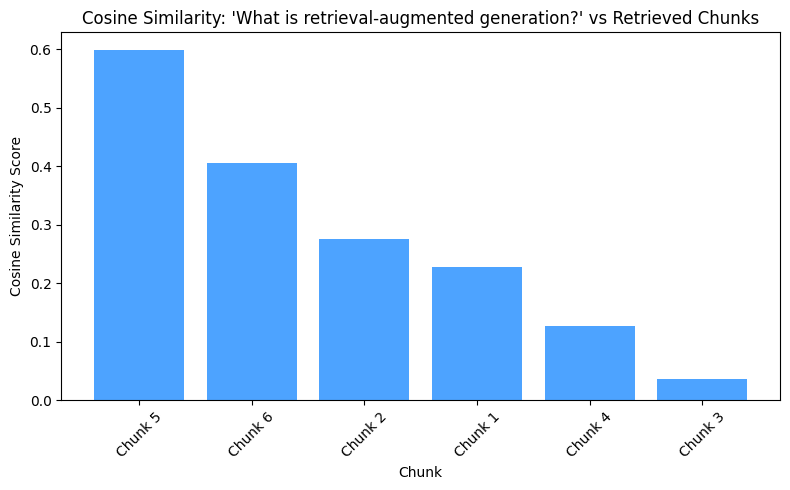

In [11]:
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt
from sentence_transformers import util

query = "What is retrieval-augmented generation?"
query_embed = embedder.encode(query, convert_to_tensor=True)
scores = util.cos_sim(query_embed, chunk_embeddings)[0]

# Sort chunks by score for a clearer chart
sorted_indices = scores.argsort(descending=True)
sorted_scores = [scores[i].item() for i in sorted_indices]
sorted_labels = [f"Chunk {i.item()+1}" for i in sorted_indices]

plt.figure(figsize=(8, 5))
plt.bar(sorted_labels, sorted_scores, color="#4da3ff")
plt.xlabel("Chunk")
plt.ylabel("Cosine Similarity Score")
plt.title(f"Cosine Similarity: '{query}' vs Retrieved Chunks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()